In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Veriyi indir ve yükle
transform = transforms.Compose([
    transforms.ToTensor(),           # 0-255 → 0-1
    transforms.Normalize((0.5,), (0.5,))  # 0-1 → -1 ile 1 arası
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train örnek sayısı:", len(train_dataset))
print("Test örnek sayısı:", len(test_dataset))
print("Görüntü shape:", train_dataset[0][0].shape)

100.0%
100.0%
100.0%
100.0%


Train örnek sayısı: 60000
Test örnek sayısı: 10000
Görüntü shape: torch.Size([1, 28, 28])


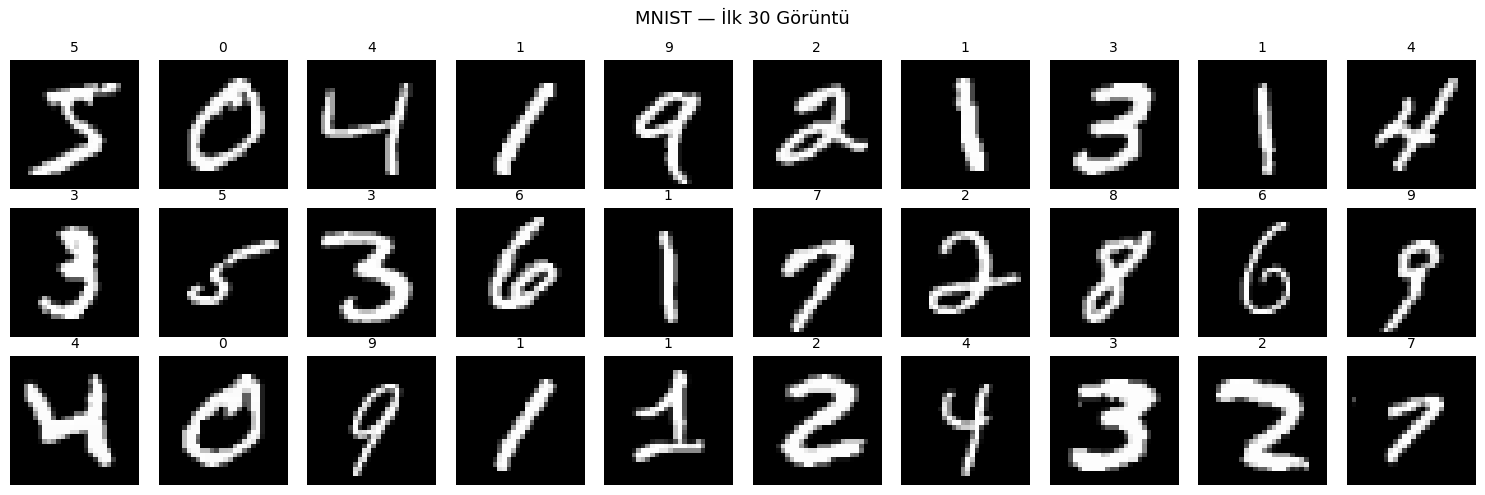

In [2]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')

plt.suptitle("MNIST — İlk 30 Görüntü", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Konvolüsyon blokları
        self.conv_layers = nn.Sequential(
            # Blok 1: 1 kanal → 32 filtre
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (32,28,28) → (32,14,14)

            # Blok 2: 32 → 64 filtre
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (32,14,14) → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2)                               # (64,14,14) → (64,7,7)
        )

        # Tam bağlı katmanlar
        self.fc_layers = nn.Sequential(
            nn.Flatten(),           # (64,7,7) → 3136
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)      # 10 rakam sınıfı
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print("\nToplam parametre:", sum(p.numel() for p in model.parameters()))

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Toplam parametre: 421642


In [4]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(5):
    # Eğitim
    model.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_dataset)

    # Test
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()

    test_loss = total_loss / len(test_loader)
    test_acc = correct / len(test_dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/5 | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

Epoch 1/5 | Train Loss: 0.1914 Acc: 94.13% | Test Loss: 0.0494 Acc: 98.50%
Epoch 2/5 | Train Loss: 0.0636 Acc: 98.15% | Test Loss: 0.0337 Acc: 98.81%
Epoch 3/5 | Train Loss: 0.0468 Acc: 98.58% | Test Loss: 0.0362 Acc: 98.88%
Epoch 4/5 | Train Loss: 0.0367 Acc: 98.85% | Test Loss: 0.0231 Acc: 99.23%
Epoch 5/5 | Train Loss: 0.0296 Acc: 99.06% | Test Loss: 0.0299 Acc: 99.06%


Toplam yanlış: 94 / 10000


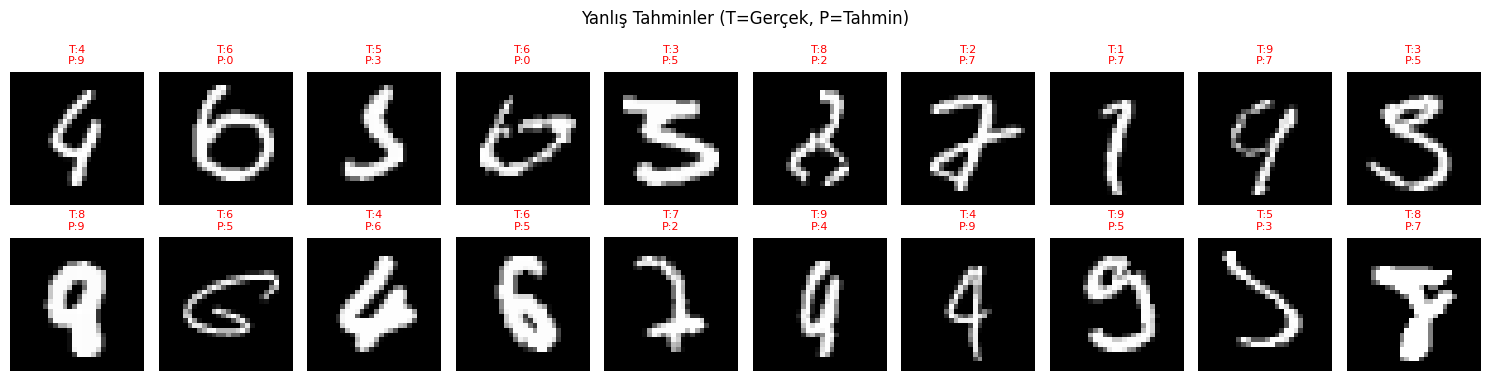

In [5]:
# Yanlış tahminleri bul
model.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        preds = output.argmax(1)
        mask = preds != y_batch

        wrong_images.extend(X_batch[mask])
        wrong_preds.extend(preds[mask].tolist())
        wrong_labels.extend(y_batch[mask].tolist())

print(f"Toplam yanlış: {len(wrong_images)} / 10000")

# İlk 20 yanlışı göster
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flatten()):
    if i >= len(wrong_images):
        ax.axis('off')
        continue
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"T:{wrong_labels[i]}\nP:{wrong_preds[i]}",
                fontsize=8,
                color='red')
    ax.axis('off')

plt.suptitle("Yanlış Tahminler (T=Gerçek, P=Tahmin)", fontsize=12)
plt.tight_layout()
plt.show()